In [1]:
import os                                                  # operating system interface
import pandas as pd                                        # data manipulation library
import matplotlib.pyplot as plt                            # plotting library
from sklearn.model_selection import train_test_split       # splits data into train/test
from sklearn.ensemble import RandomForestRegressor         # Random Forest ML model
from sklearn.metrics import mean_absolute_error, r2_score  # model evaluation metrics

os.chdir(r'C:/Users/Giannis/.vscode/01_anomaly_detector')  # set working directory

In [2]:
# define column names — 2 metadata + 3 settings + 21 sensors

columns = ['engine_id', 'cycle'] + \
          [f'setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

# load training data — sep='\s+' handles multiple spaces between values

df = pd.read_csv('data/train_FD001.txt', sep='\s+', header=None,
                  names=columns, engine='python')

df.dropna(axis=1, inplace=True)       # drop columns that are entirely empty

print(f'Dataset shape: {df.shape}')   # print rows and columns count
df.head()                             # preview first 5 rows

Dataset shape: (20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


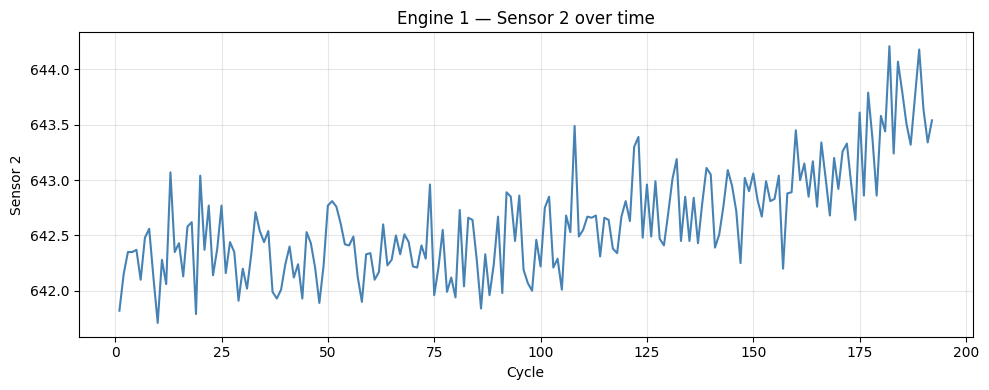

In [3]:
engine_1 = df[df['engine_id'] == 1]                              # filter data for engine 1 only

plt.figure(figsize=(10, 4))                                      # create figure with size
plt.plot(engine_1['cycle'], engine_1['sensor_2'],color='steelblue', linewidth=1.5)     # plot cycle vs sensor 2 reading
plt.xlabel('Cycle')                                              # x axis label
plt.ylabel('Sensor 2')                                           # y axis label
plt.title('Engine 1 — Sensor 2 over time')                       # plot title
plt.grid(True, alpha=0.3)                                        # add light grid
plt.tight_layout()                                               # auto adjust spacing
plt.savefig('results/engine1_sensor2.png', bbox_inches='tight')  # save plot
plt.show()                                                       # display plot

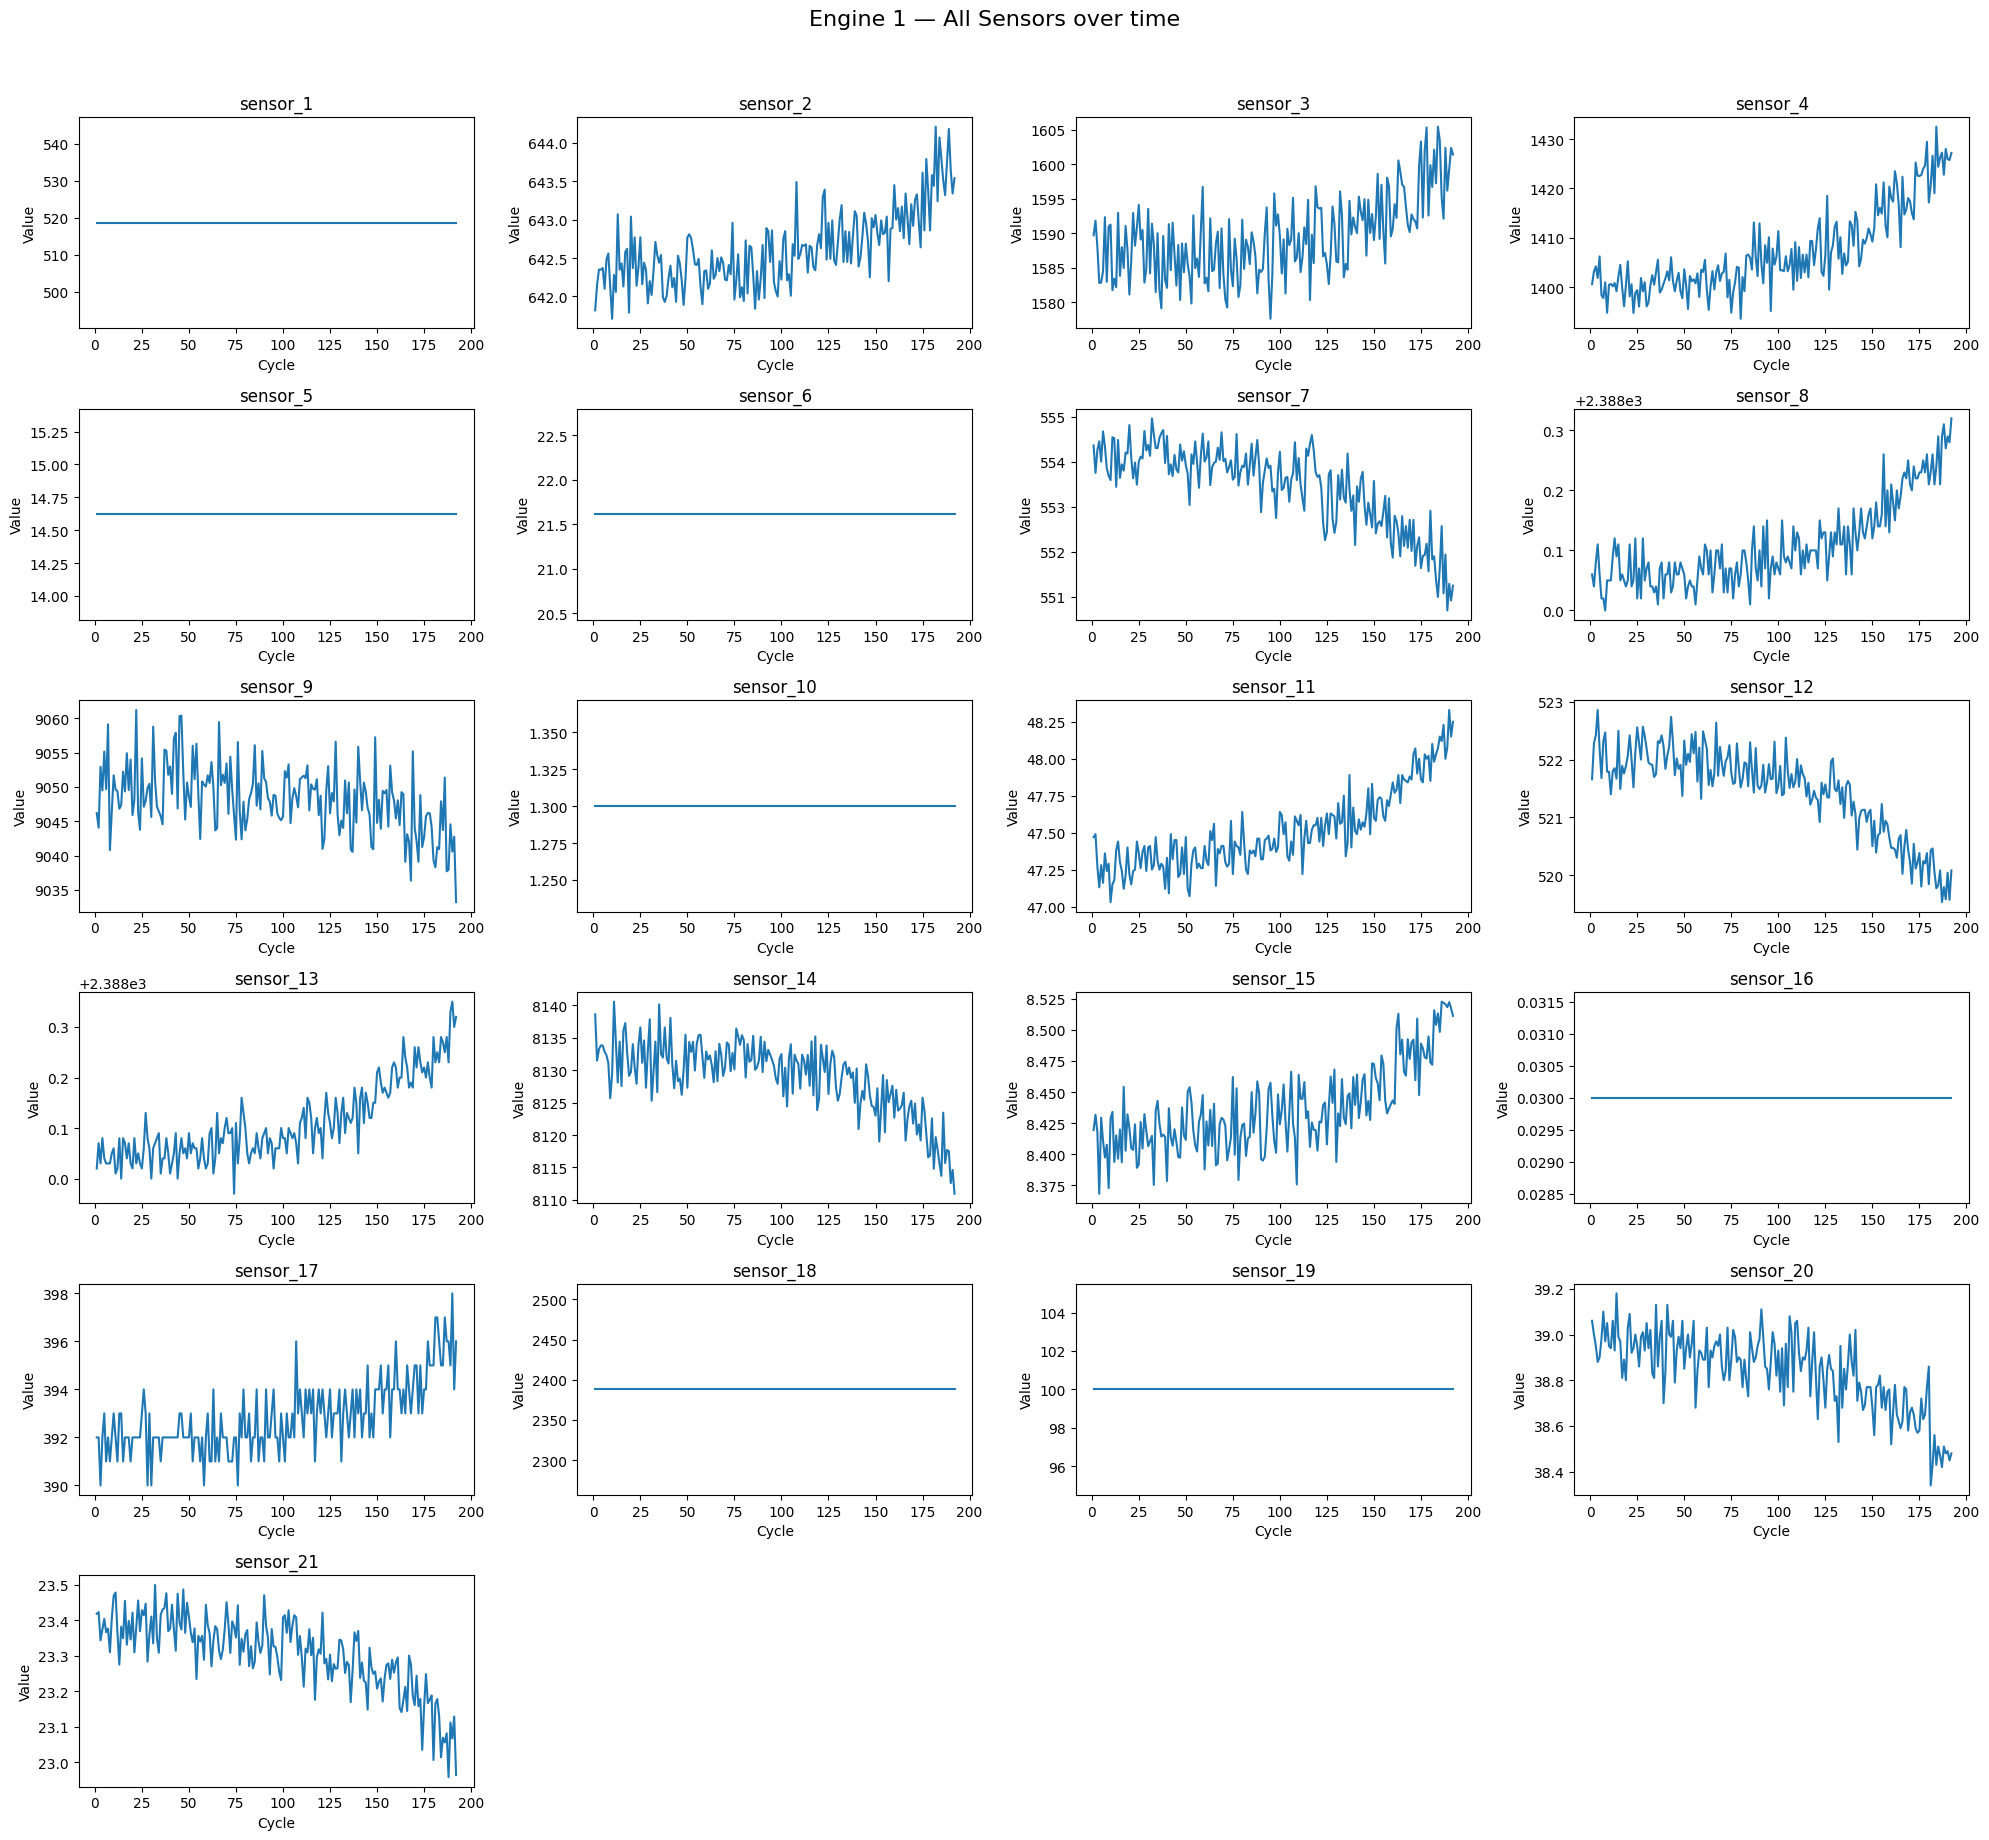

In [4]:
# get all sensor column names dynamically

sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

n = len(sensor_cols)                 # total number of sensors
ncols = 4                            # number of columns in grid
nrows = -(-n // ncols)               # ceiling division — calculates rows needed

engine_1 = df[df['engine_id'] == 1]  # filter engine 1 data

# create subplot grid — figsize scales with number of rows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 3))
axes = axes.flatten()                # flatten 2D array to 1D for easy iteration

for i, sensor in enumerate(sensor_cols):
    axes[i].plot(engine_1['cycle'], engine_1[sensor])   # plot each sensor
    axes[i].set_title(sensor)                           # sensor name as title
    axes[i].set_xlabel('Cycle')                         # x axis label
    axes[i].set_ylabel('Value')                         # y axis label

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)                          # hide unused subplot panels

plt.suptitle('Engine 1 — All Sensors over time', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('results/engine1_all_sensors.png', bbox_inches='tight')
plt.show()

In [5]:
# calculate RUL using transform — more efficient than merge
# transform applies a function per group and returns same-length result

df['RUL'] = df.groupby('engine_id')['cycle']\
              .transform(lambda x: x.max() - x)

# x.max() = total cycles before failure
# x.max() - x = remaining cycles at each point = RUL

print(df[['engine_id', 'cycle', 'RUL']].head(10))  # preview RUL values

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187
5          1      6  186
6          1      7  185
7          1      8  184
8          1      9  183
9          1     10  182


In [6]:
# calculate standard deviation per sensor — measures how much each varies

sensor_std = df[sensor_cols].std()

# print sorted by sensor number for easy reading

print(sensor_std.sort_index(key=lambda x: x.str.extract('(\d+)')[0].astype(int)))

# sensors with std ≈ 0 are flat — carry no useful information for the model

flat_sensors = ['sensor_1', 'sensor_5', 'sensor_6',
                'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

df.drop(columns=flat_sensors, inplace=True)       # remove flat sensors from dataframe

# update sensor list to reflect remaining sensors only

sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

print(f'Remaining sensors: {len(sensor_cols)}')   # confirm count
print(sensor_cols)                                # list remaining sensors

sensor_1     0.000000e+00
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    0.000000e+00
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    3.469531e-18
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64
Remaining sensors: 14
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [7]:
# sort by engine and cycle before rolling — required for correct time ordering

df = df.sort_values(['engine_id', 'cycle'])

# add 10-cycle rolling average per sensor per engine
# rolling mean smooths noise and captures degradation trend
# analogous to a low-pass filter in signal processing

for sensor in sensor_cols:
    df[f'{sensor}_rolling_mean'] = df.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    
    # window=10 → average over last 10 cycles
    # min_periods=1 → works even at start where fewer than 10 cycles exist

print('Rolling features added!')
print(f'New dataset shape: {df.shape}')  # should have doubled sensor columns

Rolling features added!
New dataset shape: (20631, 34)


In [8]:
# --- Baseline model (raw sensors only) ---

X_base = df[sensor_cols]   # features — raw sensor readings only
y = df['RUL']              # target — remaining useful life

# split 80% training, 20% testing — random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42)

# train baseline Random Forest — n_jobs=-1 uses all CPU cores for speed

model_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_base.fit(X_train, y_train)                       # fit model on training data

y_pred_base = model_base.predict(X_test)               # predict on test data
mae_base = mean_absolute_error(y_test, y_pred_base)    # average prediction error
r2_base = r2_score(y_test, y_pred_base)                # variance explained

# --- Improved model (raw sensors + rolling averages) ---

# combine raw sensors with their rolling averages as features

feature_cols = sensor_cols + [f'{s}_rolling_mean' for s in sensor_cols]

X_improved = df[feature_cols]   # expanded feature set

# same split — random_state=42 ensures identical train/test sets for fair comparison

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_improved, y, test_size=0.2, random_state=42)

# train improved model with same parameters for fair comparison

model_improved = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_improved.fit(X_train2, y_train2)             # fit on expanded features

y_pred2 = model_improved.predict(X_test2)          # predict on test data
mae2 = mean_absolute_error(y_test2, y_pred2)       # average prediction error
r2_2 = r2_score(y_test2, y_pred2)                  # variance explained

# --- Print comparison ---
print(f'{"Model":<35} {"R²":>8} {"MAE":>12}')
print('-' * 57)
print(f'{"Baseline (raw sensors)":<35} {r2_base:>8.3f} {mae_base:>10.1f} cycles')
print(f'{"Improved (+ rolling averages)":<35} {r2_2:>8.3f} {mae2:>10.1f} cycles')
print(f'\nImprovement in R²:  {r2_2 - r2_base:.3f}')
print(f'Improvement in MAE: {mae_base - mae2:.1f} cycles')

Model                                     R²          MAE
---------------------------------------------------------
Baseline (raw sensors)                 0.626       29.5 cycles
Improved (+ rolling averages)          0.827       19.1 cycles

Improvement in R²:  0.201
Improvement in MAE: 10.4 cycles


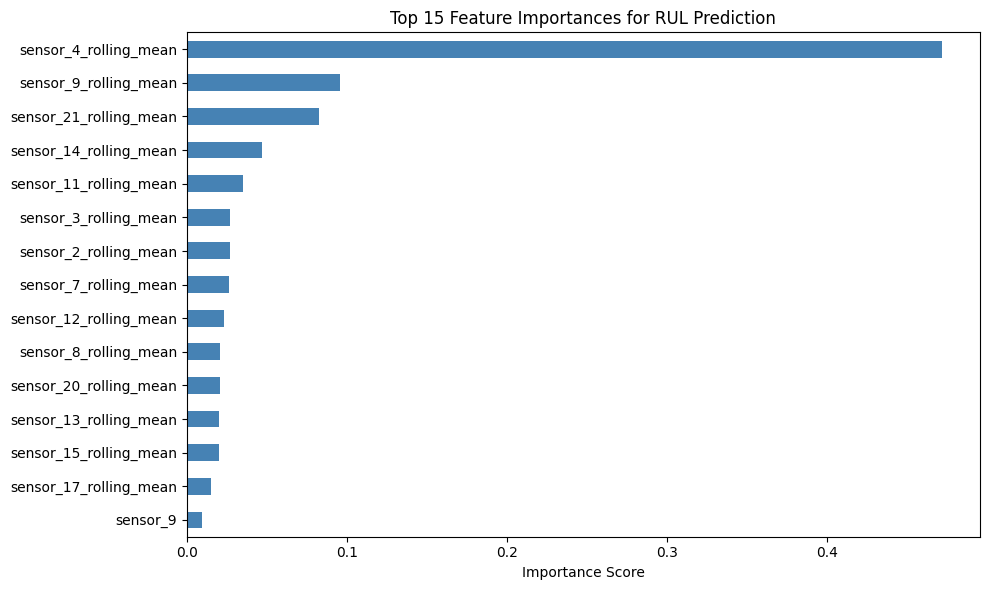

In [9]:
# extract feature importances from improved model

importances = pd.Series(model_improved.feature_importances_,index=feature_cols)

# sort and plot top 15 most important features only — cleaner visualization

importances.sort_values(ascending=True).tail(15).plot(kind='barh', figsize=(10, 6), color='steelblue')

plt.title('Top 15 Feature Importances for RUL Prediction')          # plot title
plt.xlabel('Importance Score')                                      # x axis label
plt.tight_layout()                                                  # auto adjust spacing
plt.savefig('results/feature_importance.png', bbox_inches='tight')  # save
plt.show()

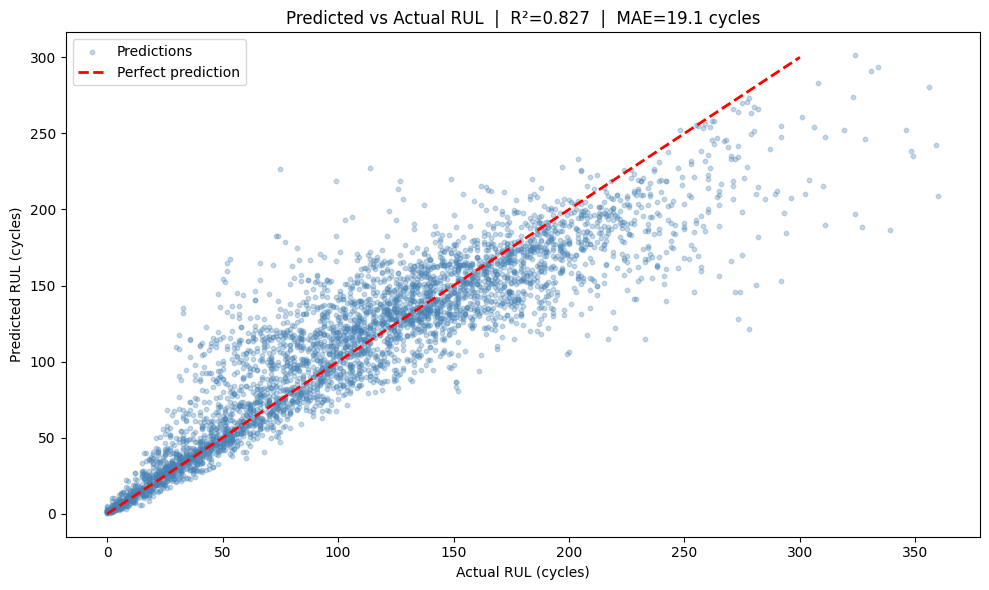

In [10]:
plt.figure(figsize=(10, 6))   # create figure

# scatter plot — each point is one engine at one cycle

plt.scatter(y_test2, y_pred2, alpha=0.3, color='steelblue',
            s=10, label='Predictions')

# perfect prediction line — all points should ideally fall on this

plt.plot([0, 300], [0, 300], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual RUL (cycles)')    # x axis — ground truth
plt.ylabel('Predicted RUL (cycles)') # y axis — model output
plt.title(f'Predicted vs Actual RUL  |  R²={r2_2:.3f}  |  MAE={mae2:.1f} cycles')
plt.legend()
plt.tight_layout()
plt.savefig('results/predictions_vs_actual.png', bbox_inches='tight')  # save
plt.show()